In [1]:
# Install packages needed for model training and evaluation
%pip install scikit-learn lightgbm joblib

  Using cached lightgbm-4.7.0-py3-none-win_amd64.whl.metadata (18 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl.metadata (24 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.3 MB 8.3 MB/s eta 0:00:01
   ------- -------------------------------- 1.6/8.3 MB 8.3 MB/s eta 0:00:01
   -------- ------------------------------- 1.8/8.3 MB 3.5 MB/s eta 0:00:02
   -------- ------------------------------- 1.8/8.3 MB 3.5 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.3 MB 2.1 MB/s eta 0:00:03
   ------------ --------------------------- 2.6/8.3 MB 2.2 MB/s eta 0:00:03
   ------------ --------------------------- 2.6/8.3 MB 2.2 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.3 MB 1.7 MB/s 


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# Load the feature-engineered dataset for model experiments
from pathlib import Path

import pandas as pd
import numpy as np

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

project_root = Path.cwd().parent
data_path = project_root / "data" / "processed" / "features.csv"

df = pd.read_csv(data_path, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())

df.head()

Shape: (2367, 19)
Date range: 2016-11-16 00:00:00 to 2023-12-17 00:00:00


,date,pm25,temperature,humidity,rainfall,wind_speed,fire_count,total_frp,mean_frp,month,day_of_year,season,pm25_lag_1,pm25_lag_2,pm25_lag_3,pm25_lag_7,pm25_roll_3,pm25_roll_7,target_pm25_next_day
0,2016-11-16,250.0,20.1,52,0.0,8.7,1180.0,8069.43,6.838500,11,321,post_monsoon,202.0,167.0,175.0,270.0,181.333333,226.428571,215.0
1,2016-11-17,215.0,20.1,50,0.0,12.5,1335.0,7768.52,5.819116,11,322,post_monsoon,250.0,202.0,167.0,259.0,206.333333,223.571429,195.0
2,2016-11-18,195.0,20.1,55,0.0,10.4,915.0,4957.63,5.418175,11,323,post_monsoon,215.0,250.0,202.0,274.0,222.333333,217.285714,201.0
3,2016-11-19,201.0,19.6,58,0.0,7.0,398.0,2239.32,5.626432,11,324,post_monsoon,195.0,215.0,250.0,238.0,220.000000,206.000000,211.0
4,2016-11-20,211.0,19.7,62,0.0,6.4,453.0,2635.18,5.817174,11,325,post_monsoon,201.0,195.0,215.0,175.0,203.666667,200.714286,198.0


In [4]:
# Remove missing values and split the data by time
df = df.dropna(
    subset=["pm25", "target_pm25_next_day"]
).reset_index(drop=True)

split_index = int(len(df) * 0.80)

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

print("Rows after final check:", len(df))
print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

print("\nTraining period:")
print(train_df["date"].min(), "to", train_df["date"].max())

print("\nTesting period:")
print(test_df["date"].min(), "to", test_df["date"].max())

print("\nMissing current PM2.5 in test:", test_df["pm25"].isna().sum())
print("Missing target in test:", test_df["target_pm25_next_day"].isna().sum())

Rows after final check: 2366
Training rows: 1892
Testing rows: 474

Training period:
2016-11-16 00:00:00 to 2022-07-05 00:00:00

Testing period:
2022-07-06 00:00:00 to 2023-12-17 00:00:00

Missing current PM2.5 in test: 0
Missing target in test: 0


In [5]:
# Create a persistence baseline using today's PM2.5 as tomorrow's prediction
y_test = test_df["target_pm25_next_day"]
baseline_pred = test_df["pm25"]

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline Model")
print(f"MAE:  {baseline_mae:.2f}")
print(f"RMSE: {baseline_rmse:.2f}")
print(f"R²:   {baseline_r2:.3f}")

Baseline Model
MAE:  21.36
RMSE: 35.67
R²:   0.808


In [6]:
# Select the features for model training
feature_columns = [
    "temperature", "humidity", "rainfall", "wind_speed",
    "fire_count", "total_frp", "mean_frp",
    "month", "day_of_year",
    "pm25_lag_1", "pm25_lag_2", "pm25_lag_3", "pm25_lag_7",
    "pm25_roll_3", "pm25_roll_7"
]

X_train = train_df[feature_columns]
X_test = test_df[feature_columns]

y_train = train_df["target_pm25_next_day"]
y_test = test_df["target_pm25_next_day"]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Missing values:", X_train.isna().sum().sum() + X_test.isna().sum().sum())

Training data: (1892, 15)
Testing data: (474, 15)
Missing values: 0


In [7]:
# Train and test a Linear Regression model
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression")
print(f"MAE:  {linear_mae:.2f}")
print(f"RMSE: {linear_rmse:.2f}")
print(f"R²:   {linear_r2:.3f}")

Linear Regression
MAE:  28.86
RMSE: 40.99
R²:   0.747


In [8]:
# Train and test a Random Forest model
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print(f"MAE:  {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R²:   {rf_r2:.3f}")

Random Forest
MAE:  27.73
RMSE: 44.95
R²:   0.696


In [9]:
# Train and test a LightGBM model
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    verbosity=-1
)

lgbm_model.fit(X_train, y_train)

lgbm_pred = lgbm_model.predict(X_test)

lgbm_mae = mean_absolute_error(y_test, lgbm_pred)
lgbm_rmse = np.sqrt(mean_squared_error(y_test, lgbm_pred))
lgbm_r2 = r2_score(y_test, lgbm_pred)

print("LightGBM")
print(f"MAE:  {lgbm_mae:.2f}")
print(f"RMSE: {lgbm_rmse:.2f}")
print(f"R²:   {lgbm_r2:.3f}")

LightGBM
MAE:  34.52
RMSE: 55.29
R²:   0.540


In [10]:
# Add today's PM2.5 to the model features
feature_columns_v2 = feature_columns + ["pm25"]

X_train_v2 = train_df[feature_columns_v2]
X_test_v2 = test_df[feature_columns_v2]

print("Training data:", X_train_v2.shape)
print("Testing data:", X_test_v2.shape)

Training data: (1892, 16)
Testing data: (474, 16)


In [11]:
# Train both models again with today's PM2.5
rf_v2 = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

lgbm_v2 = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    verbosity=-1
)

rf_v2.fit(X_train_v2, y_train)
lgbm_v2.fit(X_train_v2, y_train)

rf_v2_pred = rf_v2.predict(X_test_v2)
lgbm_v2_pred = lgbm_v2.predict(X_test_v2)

print("Random Forest V2")
print(f"MAE:  {mean_absolute_error(y_test, rf_v2_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_v2_pred)):.2f}")
print(f"R²:   {r2_score(y_test, rf_v2_pred):.3f}")

print("\nLightGBM V2")
print(f"MAE:  {mean_absolute_error(y_test, lgbm_v2_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lgbm_v2_pred)):.2f}")
print(f"R²:   {r2_score(y_test, lgbm_v2_pred):.3f}")

Random Forest V2
MAE:  21.48
RMSE: 35.79
R²:   0.807

LightGBM V2
MAE:  27.99
RMSE: 45.58
R²:   0.687


In [12]:
# Train Random Forest without fire features
features_no_fire = [
    "temperature", "humidity", "rainfall", "wind_speed",
    "month", "day_of_year",
    "pm25", "pm25_lag_1", "pm25_lag_2",
    "pm25_lag_3", "pm25_lag_7",
    "pm25_roll_3", "pm25_roll_7"
]

X_train_no_fire = train_df[features_no_fire]
X_test_no_fire = test_df[features_no_fire]

rf_no_fire = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_no_fire.fit(X_train_no_fire, y_train)
no_fire_pred = rf_no_fire.predict(X_test_no_fire)

no_fire_mae = mean_absolute_error(y_test, no_fire_pred)
no_fire_rmse = np.sqrt(mean_squared_error(y_test, no_fire_pred))
no_fire_r2 = r2_score(y_test, no_fire_pred)

print("Random Forest Without Fire")
print(f"MAE:  {no_fire_mae:.2f}")
print(f"RMSE: {no_fire_rmse:.2f}")
print(f"R²:   {no_fire_r2:.3f}")

Random Forest Without Fire
MAE:  21.56
RMSE: 36.47
R²:   0.800


In [13]:
# Compare the main model results
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest",
        "LightGBM",
        "Random Forest V2",
        "LightGBM V2",
        "Random Forest Without Fire"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        rf_mae,
        lgbm_mae,
        mean_absolute_error(y_test, rf_v2_pred),
        mean_absolute_error(y_test, lgbm_v2_pred),
        no_fire_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        rf_rmse,
        lgbm_rmse,
        np.sqrt(mean_squared_error(y_test, rf_v2_pred)),
        np.sqrt(mean_squared_error(y_test, lgbm_v2_pred)),
        no_fire_rmse
    ],
    "R2": [
        baseline_r2,
        linear_r2,
        rf_r2,
        lgbm_r2,
        r2_score(y_test, rf_v2_pred),
        r2_score(y_test, lgbm_v2_pred),
        no_fire_r2
    ]
})

results.round(3)

,Model,MAE,RMSE,R2
0,Baseline,21.364,35.667,0.808
1,Linear Regression,28.858,40.990,0.747
2,Random Forest,27.732,44.953,0.696
3,LightGBM,34.518,55.285,0.540
4,Random Forest V2,21.476,35.791,0.807
5,LightGBM V2,27.989,45.580,0.687
6,Random Forest Without Fire,21.557,36.468,0.800


In [14]:
# Find better settings for the Random Forest model
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.7, 1.0]
}

time_split = TimeSeriesSplit(n_splits=5)

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=time_split,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train_v2, y_train)

print("Best settings:")
print(rf_search.best_params_)

Best settings:
{'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 0.7, 'max_depth': None}


In [15]:
# Test the tuned Random Forest on the test data
tuned_rf = rf_search.best_estimator_
tuned_pred = tuned_rf.predict(X_test_v2)

tuned_mae = mean_absolute_error(y_test, tuned_pred)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))
tuned_r2 = r2_score(y_test, tuned_pred)

print("Tuned Random Forest")
print(f"MAE:  {tuned_mae:.2f}")
print(f"RMSE: {tuned_rmse:.2f}")
print(f"R²:   {tuned_r2:.3f}")

print("\nBaseline MAE:", round(baseline_mae, 2))

Tuned Random Forest
MAE:  21.11
RMSE: 33.73
R²:   0.829

Baseline MAE: 21.36


In [16]:
# Compare actual and predicted PM2.5 values
comparison = pd.DataFrame({
    "date": test_df["date"],
    "actual_pm25": y_test,
    "predicted_pm25": tuned_pred
})

comparison["error"] = (
    comparison["actual_pm25"] - comparison["predicted_pm25"]
).abs()

comparison.head(10)

,date,actual_pm25,predicted_pm25,error
1892,2022-07-06,33.6,48.876925,15.276925
1893,2022-07-07,28.5,28.972650,0.472650
1894,2022-07-08,36.7,32.369787,4.330213
1895,2022-07-09,27.0,33.998409,6.998409
1896,2022-07-10,34.1,32.455332,1.644668
1897,2022-07-11,20.3,40.279565,19.979565
1898,2022-07-12,30.0,30.842694,0.842694
1899,2022-07-13,25.3,34.667830,9.367830
1900,2022-07-14,21.7,26.153461,4.453461
1901,2022-07-15,20.5,23.530601,3.030601


In [17]:
# Check which features are most important to the model
importance_df = pd.DataFrame({
    "feature": feature_columns_v2,
    "importance": tuned_rf.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.reset_index(drop=True)

,feature,importance
0,pm25,0.618164
1,pm25_roll_7,0.100987
2,pm25_lag_1,0.063369
3,pm25_roll_3,0.043920
4,pm25_lag_7,0.025131
5,wind_speed,0.023715
6,temperature,0.023376
7,day_of_year,0.021082
8,rainfall,0.014648
9,pm25_lag_3,0.014199


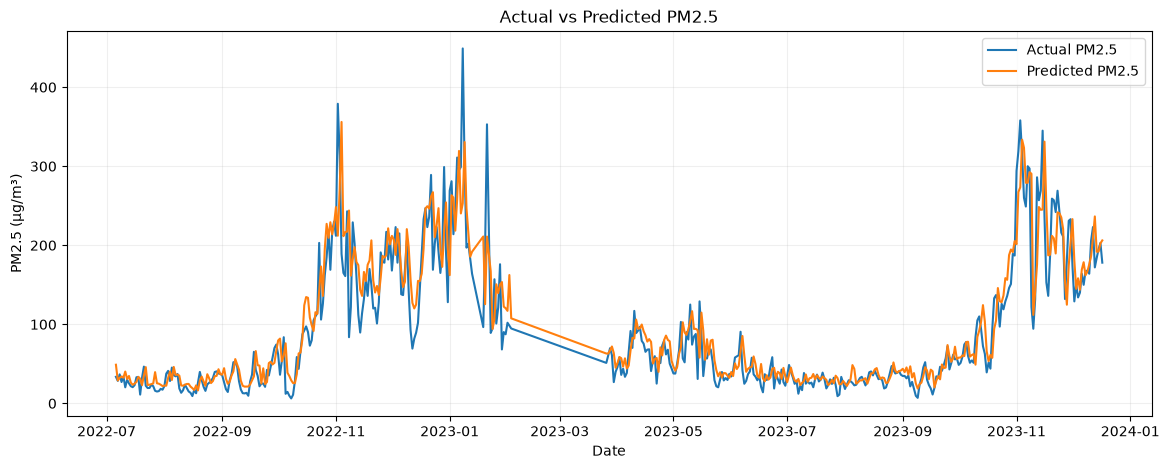

In [18]:
# Plot actual and predicted PM2.5
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    comparison["date"],
    comparison["actual_pm25"],
    label="Actual PM2.5"
)

plt.plot(
    comparison["date"],
    comparison["predicted_pm25"],
    label="Predicted PM2.5"
)

plt.title("Actual vs Predicted PM2.5")
plt.xlabel("Date")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [19]:
# Show the days where the model made the biggest errors
largest_errors = (
    comparison
    .sort_values("error", ascending=False)
    .head(10)
)

largest_errors

,date,actual_pm25,predicted_pm25,error
2078,2023-01-08,449.0,253.089008,195.910992
2327,2023-11-09,122.0,290.497868,168.497868
2013,2022-11-04,189.0,356.001479,167.001479
2011,2022-11-02,379.0,212.065180,166.934820
2017,2022-11-08,83.7,243.948796,160.248796
2086,2023-01-21,353.0,211.031420,141.968580
2084,2023-01-19,96.5,211.114520,114.614520
2330,2023-11-12,286.0,175.614910,110.385090
2071,2023-01-01,269.0,162.230438,106.769562
2333,2023-11-15,345.0,245.242619,99.757381


In [20]:
# Install SHAP for model explanations
%pip install shap

  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached tqdm-4.70.1-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached shap-0.52.0-cp312-abi3-win_amd64.whl (499 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached tqdm-4.70.1-py3-none-any.whl (80 kB)
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/41.9 MB ? eta -:--:--
    --------------------------------------- 0.5/41.9 MB 762.0 kB/s eta 0:00:55
    --------------------------------------- 0.5/41.9 MB 762.0 kB/s eta 0:00:55
    --------------------------------------- 0.8/41.9 MB 714.3 kB/s et


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


c:\Users\aayus\OneDrive\Desktop\Data Science Project\Air Quality Trend & Forecast\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


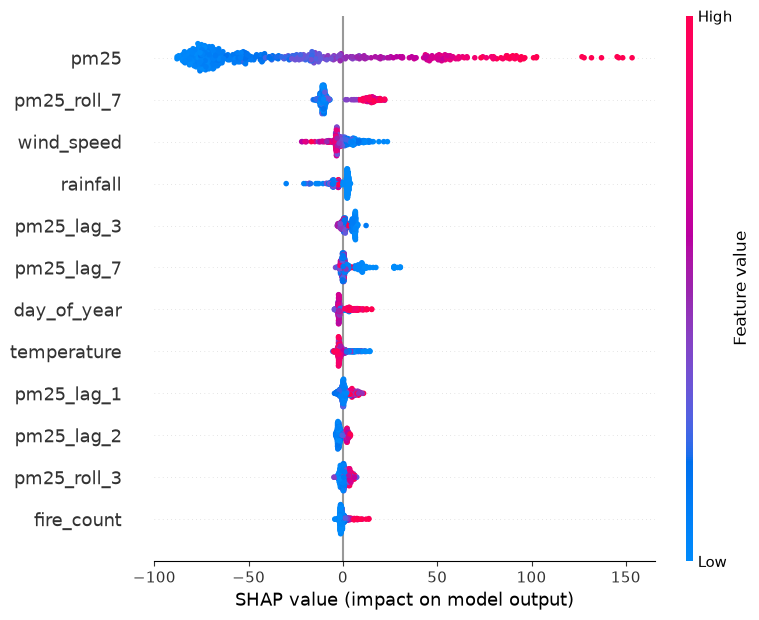

In [21]:
# Explain how each feature affects the model predictions
import shap

explainer = shap.TreeExplainer(tuned_rf)
shap_values = explainer(X_test_v2)

shap.summary_plot(
    shap_values,
    X_test_v2,
    max_display=12
)

Date: 2023-12-17 00:00:00
Actual PM2.5: 178.0
Predicted PM2.5: 206.15


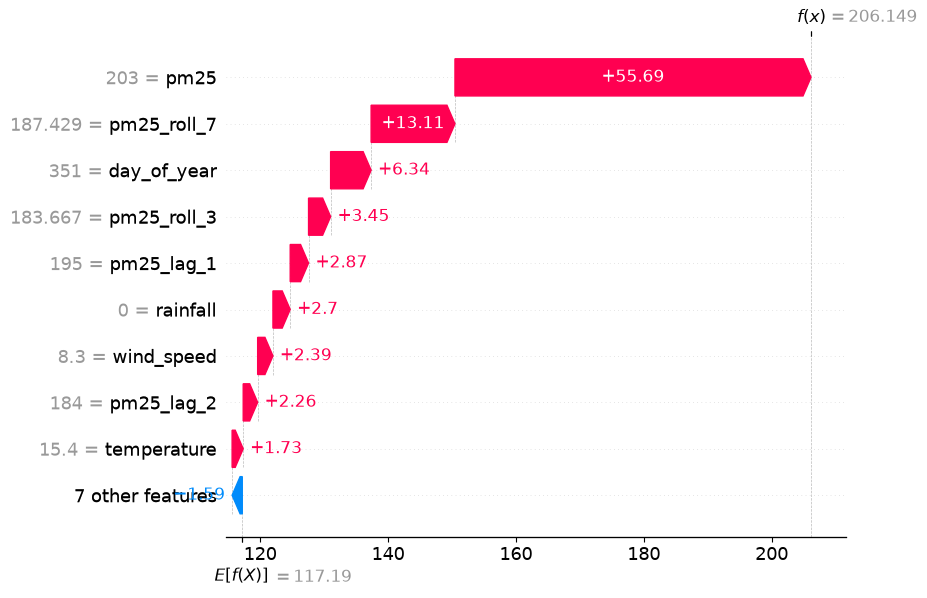

In [22]:
# Explain one PM2.5 prediction
sample_index = -1

sample = X_test_v2.iloc[[sample_index]]
sample_shap = explainer(sample)

print("Date:", test_df.iloc[sample_index]["date"])
print("Actual PM2.5:", round(y_test.iloc[sample_index], 2))
print("Predicted PM2.5:", round(tuned_rf.predict(sample)[0], 2))

shap.plots.waterfall(sample_shap[0], max_display=10)

In [23]:
# Compare the final model with the baseline
final_results = pd.DataFrame({
    "Model": ["Baseline", "Tuned Random Forest"],
    "MAE": [baseline_mae, tuned_mae],
    "RMSE": [baseline_rmse, tuned_rmse],
    "R2": [baseline_r2, tuned_r2]
})

final_results.round(3)

,Model,MAE,RMSE,R2
0,Baseline,21.364,35.667,0.808
1,Tuned Random Forest,21.113,33.729,0.829


In [24]:
# Save the final trained model
import joblib

model_path = project_root / "models" / "air_quality_model.pkl"

joblib.dump(tuned_rf, model_path)

print("Model saved:", model_path)

Model saved: c:\Users\aayus\OneDrive\Desktop\Data Science Project\Air Quality Trend & Forecast\models\air_quality_model.pkl


In [25]:
# Save the feature names used by the final model
feature_path = project_root / "models" / "feature_columns.pkl"

joblib.dump(feature_columns_v2, feature_path)

print("Features saved:", feature_path)
print("Number of features:", len(feature_columns_v2))
print(feature_columns_v2)

Features saved: c:\Users\aayus\OneDrive\Desktop\Data Science Project\Air Quality Trend & Forecast\models\feature_columns.pkl
Number of features: 16
['temperature', 'humidity', 'rainfall', 'wind_speed', 'fire_count', 'total_frp', 'mean_frp', 'month', 'day_of_year', 'pm25_lag_1', 'pm25_lag_2', 'pm25_lag_3', 'pm25_lag_7', 'pm25_roll_3', 'pm25_roll_7', 'pm25']
